# 01 URDF Combination

In [ ]:
import kinpy as kp

# urdf_path = 'urdfs/ur_description/urdf/ur5_robot.urdf'
# urdf_path = 'urdfs/DH13_right_palm_URDF/urdf/DH13_right_palm_URDF.urdf'
urdf_path = 'urdfs/ur5_dh13_combined.urdf'

txt = open(urdf_path, 'rb').read()
chain = kp.build_chain_from_urdf(txt)
print(chain)
# serial_chain = kp.build_serial_chain_from_urdf(txt, 'ee_link')
# print(serial_chain)

chain.get_joint_parameter_names()

# dir(chain)
# chain.forward_kinematics([0.1])



In [1]:
import cloudpickle as cpickle

def load_cpkl(path):
    with open(path, 'rb') as f:
        return cpickle.load(f)
    
pkl_path = 'datasets/robot/robot/robot_rawdata.pkl'
data = load_cpkl(pkl_path)
data


{'save_freq': 0.5,
 'num_steps': 30591,
 'cam_K': array([[616.99243,   0.     , 314.10406],
        [  0.     , 616.9546 , 236.41193],
        [  0.     ,   0.     ,   1.     ]], dtype=float32),
 'eef_pose_list': [array([ 0.5592351 ,  0.01731292,  0.3996791 , -0.26527479,  0.88532478,
          0.30255493,  0.23300174]),
  array([ 0.55923513,  0.01731272,  0.3996791 , -0.26527456,  0.8853249 ,
          0.30255483,  0.23300175]),
  array([ 0.5592351 ,  0.01731298,  0.3996791 , -0.26527468,  0.88532484,
          0.30255498,  0.23300167]),
  array([ 0.55923514,  0.01731281,  0.39967918, -0.2652746 ,  0.88532484,
          0.30255482,  0.23300184]),
  array([ 0.55923518,  0.01731297,  0.39967916, -0.26527472,  0.88532484,
          0.30255485,  0.23300178]),
  array([ 0.55923515,  0.01731286,  0.39967913, -0.26527463,  0.88532484,
          0.30255496,  0.23300171]),
  array([ 0.55923513,  0.01731286,  0.39967908, -0.26527463,  0.88532484,
          0.30255489,  0.23300171]),
  array([ 0

In [8]:
import cloudpickle as cpickle

def load_cpkl(path):
    with open(path, 'rb') as f:
        return cpickle.load(f)
    
# pkl_path = 'datasets/robot/robot/predefined_motion_graphs/000320.pkl'
pkl_path = 'datasets/robot/ep1/predefined_motion_graphs/frame_000000.pkl'
data = load_cpkl(pkl_path)
print(data['joints'].shape)
print(data['link_poses'].shape)
print(len(data['joints']))
data

torch.Size([25, 3])
torch.Size([24, 4, 4])
25


{'joints': tensor([[ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0892],
         [-0.1336,  0.0246,  0.0892],
         [ 0.0462,  0.3397,  0.3409],
         [ 0.1157,  0.7172,  0.2600],
         [ 0.0242,  0.7340,  0.2600],
         [ 0.0213,  0.7180,  0.3533],
         [-0.0410,  0.7714,  0.3605],
         [-0.0410,  0.7714,  0.3605],
         [-0.1285,  0.8731,  0.3964],
         [-0.1285,  0.8731,  0.3964],
         [-0.0937,  0.8638,  0.3790],
         [-0.1153,  0.8564,  0.3984],
         [-0.1440,  0.8581,  0.3735],
         [-0.1440,  0.8581,  0.3735],
         [-0.1090,  0.8487,  0.3566],
         [-0.1305,  0.8409,  0.3760],
         [-0.1595,  0.8431,  0.3505],
         [-0.1595,  0.8431,  0.3505],
         [-0.1247,  0.8332,  0.3335],
         [-0.1466,  0.8262,  0.3528],
         [-0.0534,  0.8132,  0.3917],
         [-0.0534,  0.8132,  0.3917],
         [-0.0779,  0.8224,  0.3526],
         [-0.1032,  0.7968,  0.2979]]),
 'joint_names': ['world',
  'shoulder_

# 02 SAPIEN

In [ ]:
import sapien as sapien
from sapien.utils import Viewer
import numpy as np


def main():
    scene = sapien.Scene()  # Create an instance of simulation world (aka scene)
    scene.set_timestep(1 / 100.0)  # Set the simulation frequency

    # NOTE: How to build (rigid bodies) is elaborated in create_actors.py
    scene.add_ground(altitude=0)  # Add a ground
    actor_builder = scene.create_actor_builder()
    actor_builder.add_box_collision(half_size=[0.5, 0.5, 0.5])
    actor_builder.add_box_visual(half_size=[0.5, 0.5, 0.5], material=[1.0, 0.0, 0.0])
    box = actor_builder.build(name="box")  # Add a box
    box.set_pose(sapien.Pose(p=[0, 0, 0.5]))

    # Add some lights so that you can observe the scene
    scene.set_ambient_light([0.5, 0.5, 0.5])
    scene.add_directional_light([0, 1, -1], [0.5, 0.5, 0.5])

    viewer = scene.create_viewer()  # Create a viewer (window)

    # The coordinate frame in Sapien is: x(forward), y(left), z(upward)
    # The principle axis of the camera is the x-axis
    viewer.set_camera_xyz(x=-4, y=0, z=2)
    # The rotation of the free camera is represented as [roll(x), pitch(-y), yaw(-z)]
    # The camera now looks at the origin
    viewer.set_camera_rpy(r=0, p=-np.arctan2(2, 4), y=0)
    viewer.window.set_camera_parameters(near=0.05, far=100, fovy=1)

    while not viewer.closed:  # Press key q to quit
        scene.step()  # Simulate the world
        scene.update_render()  # Update the world to the renderer
        viewer.render()


if __name__ == "__main__":
    main()

In [13]:
import sapien


def demo(fix_root_link, balance_passive_force):
    scene = sapien.Scene()
    scene.add_ground(0)

    scene.set_ambient_light([0.5, 0.5, 0.5])
    scene.add_directional_light([0, 1, -1], [0.5, 0.5, 0.5])

    viewer = scene.create_viewer()
    viewer.set_camera_xyz(x=-2, y=0, z=1)
    viewer.set_camera_rpy(r=0, p=-0.3, y=0)

    # Load URDF
    loader = scene.create_urdf_loader()
    loader.fix_root_link = fix_root_link
    robot: sapien.Articulation = loader.load("./urdfs/DH13_right_palm_URDF/urdf/DH13_right_palm_URDF.urdf")
    # robot: sapien.Articulation = loader.load("./urdfs/ur_description/urdf/ur5_robot.urdf")
    # robot: sapien.Articulation = loader.load("./urdfs/ur5_dh13_combined.urdf")
    robot.set_root_pose(sapien.Pose([0, 0, 0], [1, 0, 0, 0]))

    # # Set initial joint positions
    # arm_init_qpos = [4.71, 2.84, 0, 0.75, 4.62, 4.48, 4.88]
    # gripper_init_qpos = [0, 0, 0, 0, 0, 0]
    # init_qpos = arm_init_qpos + gripper_init_qpos
    # robot.set_qpos(init_qpos)

    while not viewer.closed:
        # for _ in range(4):  # render every 4 steps
        #     if balance_passive_force:
        #         qf = robot.compute_passive_force(
        #             gravity=True,
        #             coriolis_and_centrifugal=True,
        #         )
        #         robot.set_qf(qf)
        #     scene.step()
        scene.step()
        scene.update_render()
        viewer.render()


demo(fix_root_link=True, balance_passive_force=True)

# 03 Data Process

In [1]:
import os
import cv2
import json
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import sys

base_path = 'new_data/ep1'
output_path = 'datasets/robot/ur5_ep1'
os.makedirs(output_path, exist_ok=True)

video_path = os.path.join(base_path, 'video.mp4')
csv_path_1 = os.path.join(base_path, 'ur5_frame_data.csv')
csv_path_2 = os.path.join(base_path, 'dexh13_frame_data.csv')

df_1 = pd.read_csv(csv_path_1)
df_2 = pd.read_csv(csv_path_2)


def extract_and_align(video_path, df_1, df_2, output_dir, save_per_frame_json=False, fallback_fill_last=True):
    cap = cv2.VideoCapture(video_path)
    assert cap.isOpened(), f"无法打开视频: {video_path}"

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"视频: {video_path}\n尺寸: {width}x{height}, FPS: {fps:.3f}, 帧数: {frame_count}")

    # 准备聚合 JSON 容器
    aligned = {
        'video_path': video_path,
        'fps': float(fps),
        'frame_count': int(frame_count),
        'frames': []
    }

    idx_map = lambda i: i

    for i in tqdm(range(frame_count), desc='Extracting frames'):
        ret, frame = cap.read()
        assert ret, f"第 {i} 帧读取失败"

        # 保存帧图像
        img_name = f"frame_{i:06d}.png"
        img_dir = os.path.join(output_dir, 'rgb')
        os.makedirs(img_dir, exist_ok=True)
        img_path = os.path.join(img_dir, img_name)
        cv2.imwrite(img_path, frame)

        # 选择 CSV 行
        assert len(df_1) == len(df_2), "两个 CSV 的行数不匹配"
        j = idx_map(i)
        if j >= len(df_1):
            if fallback_fill_last and len(df_1) > 0:
                j = len(df_1) - 1
            else:
                # 无可对齐数据，记录空
                pose_dict = {}
                frame_item = {
                    'frame_index': i,
                    'image': img_path,
                    'pose': pose_dict
                }
                aligned['frames'].append(frame_item)
                if save_per_frame_json:
                    with open(os.path.join(output_dir, f"frame_{i:06d}.json"), 'w', encoding='utf-8') as f:
                        json.dump(frame_item, f, ensure_ascii=False, indent=2)
                continue

        pose_series_1 = df_1.iloc[j]
        pose_series_2 = df_2.iloc[j]

        # 确保可序列化
        pose_dict_1 = {k: (None if pd.isna(v) else (float(v) if isinstance(v, (int, float, np.floating)) else v))
                     for k, v in pose_series_1.to_dict().items()}
        pose_dict_2 = {k: (None if pd.isna(v) else (float(v) if isinstance(v, (int, float, np.floating)) else v))
                     for k, v in pose_series_2.to_dict().items()}
        pose_dict_2 = {k: v / 180 * 3.141592653589793 for k, v in pose_dict_2.items() if k.startswith('joint_')}  # NOTE degree to radian conversion
        pose_dict = {
            'ur5': pose_dict_1,
            'dexh13': pose_dict_2
        }

        frame_item = {
            'frame_index': i,
            'csv_index': int(j),
            'image': img_path,
            'pose': pose_dict
        }
        aligned['frames'].append(frame_item)

        if save_per_frame_json:
            with open(os.path.join(output_dir, f"frame_{i:06d}.json"), 'w', encoding='utf-8') as f:
                json.dump(frame_item, f, ensure_ascii=False, indent=2)

    cap.release()

    # 写聚合 JSON
    out_json = os.path.join(output_dir, 'frame_pose_alignment.json')
    with open(out_json, 'w', encoding='utf-8') as f:
        json.dump(aligned, f, ensure_ascii=False, indent=2)

    print(f"Extracted images to: {img_dir}")
    print(f"Extracted aligned JSON: {out_json}")
    return aligned

def prepare_sam2_json(output_path, image_dir, start = 0, end = 499, exp_name='ur5'):
    sam2_json_data = {
        "name": f"{exp_name}:center",
        "instances": [
            f"{exp_name}:kinematic"
        ],
        "root": None,
        "frames": [],
        "output_path": "instance"
    }

    for idx in range(start, end + 1):
        rgb_path = os.path.join(image_dir, f"frame_{idx:06d}.png")
        if os.path.exists(rgb_path):
            sam2_json_data['frames'].append(f'rgb/frame_{idx:06d}.png')
        else:
            print(f"Warning: {rgb_path} does not exist.")

    with open(os.path.join(output_path, 'sam2_task_center.json'), 'w') as f:
        json.dump(sam2_json_data, f, indent=4)
        print(f"Saved SAM2 JSON to {os.path.join(output_path, 'sam2_task_center.json')}")

    return sam2_json_data

def prepare_camera_json(output_path, start = 0, end = 499):
    camera_json = {
        "focal_length": 606.39587402,
        "image_size": [
            640,
            480
        ],
        "orientation": [
           [9.99992341e-01, -3.55597271e-03, -1.63478720e-03],
           [-3.75865956e-03, -7.56148583e-01, -6.54389175e-01],
           [1.09084802e-03, 6.54390308e-01, -7.56156158e-01]
        ],
        "position": [
           8.82112718e-02,
            -1.23837034e+00,
            9.00782366e-01
        ],
        "pixel_aspect_ratio": 1.0,
        "principal_point": [
            322.22705078,
            249.19195557
        ],
        "radial_distortion": [
            0.0,
            0.0,
            0.0
        ],
        "skew": 0.0,
        "tangential_distortion": [
            0.0,
            0.0
        ]
    }

    # camera_json = {
    #     "focal_length": 606.39587402,
    #     "image_size": [
    #         640,
    #         480
    #     ],
    #     "orientation": [
    #        [9.99992341e-01, -3.75865956e-03,  1.09084802e-03],
    #        [-3.55597271e-03, -7.56148583e-01,  6.54390308e-01],
    #        [-1.63478720e-03, -6.54389175e-01, -7.56156158e-01]
    #     ],
    #     "position": [
    #       -9.11416199e-02,
    #         -3.46598194e-01,
    #         1.49141346e+00
    #     ],
    #     "pixel_aspect_ratio": 1.0,
    #     "principal_point": [
    #         322.22705078,
    #         249.19195557
    #     ],
    #     "radial_distortion": [
    #         0.0,
    #         0.0,
    #         0.0
    #     ],
    #     "skew": 0.0,
    #     "tangential_distortion": [
    #         0.0,
    #         0.0
    #     ]
    # }

    # camera_json = {
    #     "focal_length": 606.39587402,
    #     "image_size": [
    #         640,
    #         480
    #     ],
    #     "orientation": [
    #        [-9.99992341e-01, 3.55597271e-03, 1.63478720e-03],
    #        [3.75865956e-03, 7.56148583e-01, 6.54389175e-01],
    #        [-1.09084802e-03, -6.54390308e-01, 7.56156158e-01]
    #     ],
    #     "position": [
    #        -8.82112718e-02,
    #         +1.23837034e+00,
    #         -9.00782366e-01
    #     ],
    #     "pixel_aspect_ratio": 1.0,
    #     "principal_point": [
    #         322.22705078,
    #         249.19195557
    #     ],
    #     "radial_distortion": [
    #         0.0,
    #         0.0,
    #         0.0
    #     ],
    #     "skew": 0.0,
    #     "tangential_distortion": [
    #         0.0,
    #         0.0
    #     ]
    # }


#     相机到机器人坐标系的变换矩阵 (T_robot_cam):
# [[ 9.99992341e-01 -3.75865956e-03  1.09084802e-03  8.82112718e-02]
#  [-3.55597271e-03 -7.56148583e-01  6.54390308e-01 -1.23837034e+00]
#  [-1.63478720e-03 -6.54389175e-01 -7.56156158e-01  9.00782366e-01]
#  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

# 外参矩阵，机器人到相机坐标系的变换矩阵 (T_cam_robot):
# [[ 9.99992341e-01 -3.55597271e-03 -1.63478720e-03 -9.11416199e-02]
#  [-3.75865956e-03 -7.56148583e-01 -6.54389175e-01 -3.46598194e-01]
#  [ 1.09084802e-03  6.54390308e-01 -7.56156158e-01  1.49141346e+00]
#  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


    camera_dir = os.path.join(output_path, 'camera')
    os.makedirs(camera_dir, exist_ok=True)

    for idx in range(start, end + 1):
        with open(os.path.join(camera_dir, f"frame_{idx:06d}.json"), 'w') as f:
            json.dump(camera_json, f, indent=4)
    print(f"Saved camera JSON files to {camera_dir}")

    return camera_json



In [2]:
# 执行逐帧提取与位姿对齐
# aligned = extract_and_align(
#     video_path,
#     df_1,
#     df_2,
#     output_path,
#     save_per_frame_json=False,
#     fallback_fill_last=True
# )

# sam2_json = prepare_sam2_json(output_path, 
#     os.path.join(output_path, 'rgb'), 
#     start=0, 
#     end=499, 
#     exp_name='ur5'
# )

camera_json = prepare_camera_json(output_path, start=0, end=499)


Saved camera JSON files to datasets/robot/ur5_ep1/camera


In [15]:
# Grounded-SAM-2 for instance segmentation
import os
os.environ['PYTHONPATH'] = os.environ.get('PYTHONPATH', '') + ':Grounded-SAM-2/'
os.system(f'port=8891 ckpt_dir=Grounded-SAM-2/checkpoints bash ./motionblender/preproc/sam2gui/run_gui_app.sh ./{output_path}/sam2_task_center.json')


/home/zhangwenkang/Projects/MBGS/Grounded-SAM-2/sam2/modeling/sam/transformer.py:23: UserWarning: You are using PyTorch 2.1.2+cu121 without Flash Attention v2 support. Consider upgrading to PyTorch 2.2+ for Flash Attention v2 (which could be faster).
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/home/zhangwenkang/miniconda3/envs/rsrd/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
2025-08-20 15:47:51.264 | INFO     | __main__:init_sam_model:127 - loaded model checkpoint Grounded-SAM-2/checkpoints/sam2.1_hiera_large.pt
2025-08-20 15:47:51.301 | DEBUG    | __main__:set_input_image:191 - Setting frame 0 / 0


* Running on local URL:  http://127.0.0.1:8891

To create a public link, set `share=True` in `launch()`.


2025-08-20 15:48:04.011 | DEBUG    | __main__:select_media:396 - Selected task: ur5:center
/home/zhangwenkang/miniconda3/envs/rsrd/lib/python3.10/site-packages/imageio_ffmpeg/_utils.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
2025-08-20 15:48:07.769 | DEBUG    | __main__:set_input_image:191 - Setting frame 0 / 500
frame loading (JPEG / PNG): 100%|██████████| 500/500 [00:05<00:00, 96.05it/s]
/home/zhangwenkang/Projects/MBGS/Grounded-SAM-2/sam2/sam2_video_predictor.py:961: UserWarning: cannot import name '_C' from 'sam2' (/home/zhangwenkang/Projects/MBGS/Grounded-SAM-2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functi

Keyboard interruption in main thread... closing server.


2

In [51]:
# extract depth images
def prepare_depth(video_path, output_path):
    original_cwd = os.getcwd()
    video_depth_anything_path = os.path.join(original_cwd, 'Video-Depth-Anything/metric_depth')
    os.chdir(video_depth_anything_path)
    os.system(f'python3 run.py --input_video ../../{video_path} --output_dir ../../{output_path} --encoder vitl --save_npz')

    os.chdir(original_cwd)

def extract_depth_images(video_path, output_dir):
    npz_path = os.path.join(output_dir, 'depth', 'video_depths.npz')
    if not os.path.exists(npz_path):
        print(f"Depth data not found at {npz_path}. Please run prepare_depth first.")
        prepare_depth(video_path, os.path.join(output_dir, 'depth'))
        
    depth_data = np.load(npz_path, allow_pickle=True)
    depth_images = depth_data['depths']
    depth_dir = os.path.join(output_dir, 'metric_depth')
    os.makedirs(depth_dir, exist_ok=True)
    # save each depth image as npy
    for i, depth_image in enumerate(tqdm(depth_images, desc="Saving depth images as npy")):
        depth_image_path = os.path.join(depth_dir, f"frame_{i:06d}.npy")
        np.save(depth_image_path,  1 / depth_image) # Save the inverse depth
extract_depth_images(video_path,output_path)

Saving depth images as npy: 100%|██████████| 1668/1668 [00:01<00:00, 1553.42it/s]


In [57]:
# use raw depth data from depth camera
import numpy as np
import os
from tqdm import tqdm


ori_path = 'new_data/ep1/depth_data'
depth_data_dir = os.path.join(output_path, 'metric_depth')
os.makedirs(depth_data_dir, exist_ok=True)

cur_id = 0
for depth_file in tqdm(sorted(os.listdir(ori_path)), desc="Processing depth files"):
    
    if depth_file.endswith('.npy'):
        src_path = os.path.join(ori_path, depth_file)
        dst_path = os.path.join(depth_data_dir, frame_name := f"frame_{cur_id:06d}.npy")
        data = np.load(src_path)
        data[data == 0] = 1e9
        # print(data.max(), data.min(), data.mean())
        np.save(dst_path, 1000 / data)  # Save the raw depth data
    cur_id += 1

Processing depth files: 100%|██████████| 1668/1668 [00:02<00:00, 815.84it/s]


In [14]:
# extract joint poses and link poses

import numpy as np
import kinpy as kp
import torch
import json
import os
import pickle


robot_joints = [
                'world', # fixed
                'shoulder_pan_joint',
                'shoulder_lift_joint',
                'elbow_joint',
                'wrist_1_joint',
                'wrist_2_joint',
                'wrist_3_joint',
                'ee_fixed_joint', # fixed
                'bracket_to_dh13', # fixed
                'right_index_joint_0',
                'right_index_joint_1',
                'right_index_joint_2',
                'right_index_joint_3',
                'right_middle_joint_0',
                'right_middle_joint_1',
                'right_middle_joint_2',
                'right_middle_joint_3',
                'right_ring_joint_0',
                'right_ring_joint_1',
                'right_ring_joint_2',
                'right_ring_joint_3',
                'right_thumb_joint_0',
                'right_thumb_joint_1',
                'right_thumb_joint_2',
                'right_thumb_joint_3'
                ]



robot_joints_from_origin = {                
            'world': 'base_link', # fixed
            'shoulder_pan_joint': 'shoulder_link',
            'shoulder_lift_joint': 'upper_arm_link',
            'elbow_joint': 'forearm_link',
            'wrist_1_joint': 'wrist_1_link',
            'wrist_2_joint': 'wrist_2_link',
            'wrist_3_joint': 'wrist_3_link',
            'ee_fixed_joint': 'ee_link', # fixed
            'bracket_to_dh13': 'right_palm_link', # fixed
            'right_index_joint_0': 'right_index_link_0',
            'right_index_joint_1': 'right_index_link_1',
            'right_index_joint_2': 'right_index_link_2',
            'right_index_joint_3': 'right_index_link_3',
            'right_middle_joint_0': 'right_middle_link_0',
            'right_middle_joint_1': 'right_middle_link_1',
            'right_middle_joint_2': 'right_middle_link_2',
            'right_middle_joint_3': 'right_middle_link_3',
            'right_ring_joint_0': 'right_ring_link_0',
            'right_ring_joint_1': 'right_ring_link_1',
            'right_ring_joint_2': 'right_ring_link_2',
            'right_ring_joint_3': 'right_ring_link_3',
            'right_thumb_joint_0': 'right_thumb_link_0',
            'right_thumb_joint_1': 'right_thumb_link_1',
            'right_thumb_joint_2': 'right_thumb_link_2',
            'right_thumb_joint_3': 'right_thumb_link_3'
        }

robot_connections = [
    ('world', 'shoulder_pan_joint'),
    ('shoulder_pan_joint', 'shoulder_lift_joint'),
    ('shoulder_lift_joint', 'elbow_joint'),
    ('elbow_joint', 'wrist_1_joint'),
    ('wrist_1_joint', 'wrist_2_joint'),
    ('wrist_2_joint', 'wrist_3_joint'),
    ('wrist_3_joint', 'ee_fixed_joint'),
    ('ee_fixed_joint', 'bracket_to_dh13'),

    ('bracket_to_dh13', 'right_index_joint_0'),
    ('right_index_joint_0', 'right_index_joint_1'),
    ('right_index_joint_1', 'right_index_joint_2'),
    ('right_index_joint_2', 'right_index_joint_3'),

    ('bracket_to_dh13', 'right_middle_joint_0'),
    ('right_middle_joint_0', 'right_middle_joint_1'),
    ('right_middle_joint_1', 'right_middle_joint_2'),
    ('right_middle_joint_2', 'right_middle_joint_3'),

    ('bracket_to_dh13', 'right_ring_joint_0'),
    ('right_ring_joint_0', 'right_ring_joint_1'),
    ('right_ring_joint_1', 'right_ring_joint_2'),
    ('right_ring_joint_2', 'right_ring_joint_3'),

    ('bracket_to_dh13', 'right_thumb_joint_0'),
    ('right_thumb_joint_0', 'right_thumb_joint_1'),
    ('right_thumb_joint_1', 'right_thumb_joint_2'),
    ('right_thumb_joint_2', 'right_thumb_joint_3')
]

default_joint_values = {
    'world': 0.0,  # fixed

    'shoulder_pan_joint': 0.0,
    'shoulder_lift_joint': 0.0,
    'elbow_joint': 0.0,
    'wrist_1_joint': 0.0,
    'wrist_2_joint': 0.0,
    'wrist_3_joint': 0.0,

    'ee_fixed_joint': 0.0,  # fixed
    'bracket_to_dh13': 0.0,  # fixed

    'right_index_joint_0': 0.0,
    'right_index_joint_1': 0.17453292519943295,
    'right_index_joint_2': 0.17453292519943295,
    'right_index_joint_3': 0.0,
    'right_middle_joint_0': 0.0,
    'right_middle_joint_1': 0.17453292519943295,
    'right_middle_joint_2': 0.17453292519943295,
    'right_middle_joint_3': 0.0,
    'right_ring_joint_0': 0.0,
    'right_ring_joint_1': 0.17453292519943295,
    'right_ring_joint_2': 0.17453292519943295,
    'right_ring_joint_3': 0.0,
    'right_thumb_joint_0': 0.0,
    'right_thumb_joint_1': 0.0,
    'right_thumb_joint_2': 0.0,
    'right_thumb_joint_3': 0.0
}

joint_map = {
    'q0': 'shoulder_pan_joint',
    'q1': 'shoulder_lift_joint',
    'q2': 'elbow_joint',
    'q3': 'wrist_1_joint',
    'q4': 'wrist_2_joint',
    'q5': 'wrist_3_joint',

    'joint_0' : 'right_index_joint_0',
    'joint_1' : 'right_index_joint_1',
    'joint_2' : 'right_index_joint_2', 
    'joint_3' : 'right_index_joint_3',
    'joint_4' : 'right_middle_joint_0',
    'joint_5' : 'right_middle_joint_1',
    'joint_6' : 'right_middle_joint_2',
    'joint_7' : 'right_middle_joint_3',
    'joint_8' : 'right_ring_joint_0',
    'joint_9' : 'right_ring_joint_1',
    'joint_10': 'right_ring_joint_2',
    'joint_11': 'right_ring_joint_3',
    'joint_12': 'right_thumb_joint_0',
    'joint_13': 'right_thumb_joint_1',
    'joint_14': 'right_thumb_joint_2',
    'joint_15': 'right_thumb_joint_3'
}

pose_json_data = {
    'joints': None,
    'joint_names': robot_joints,
    'type': 'kinematic',
    'links': [],
    'link_poses': None
}

robot_connections_int = [(robot_joints.index(a), robot_joints.index(b)) for a, b in robot_connections]
pose_json_data['links'] = robot_connections_int
pose_json_data['joint_names'] = robot_joints


ur5_path="urdfs/ur5_dh13_combined.urdf"
framewise_json_data_path = os.path.join(output_path, 'frame_pose_alignment.json')

output_pkl_path = os.path.join(output_path, 'predefined_motion_graphs')
os.makedirs(output_pkl_path, exist_ok=True)

txt = open(ur5_path, 'rb').read()
ur5_chain = kp.build_chain_from_urdf(txt)
# ur5_chain.get_joint_parameter_names()

with open(framewise_json_data_path, 'r') as f:
    framewise_json_data = json.load(f)
    frame_count = framewise_json_data['frame_count']
    framewise_data_list = framewise_json_data['frames']

for i, frame in enumerate(framewise_data_list):
    joints = torch.zeros((len(robot_joints), 3), dtype=torch.float32)
    link_poses = torch.zeros((len(robot_joints) - 1, 4, 4), dtype=torch.float32)
    for j, joint_name in enumerate(robot_joints):
        cur_pose = {**frame['pose']['ur5'], **frame['pose']['dexh13']}
        for k, v in joint_map.items():
            default_joint_values[v] = cur_pose[k]
        # print('default_joint_values', default_joint_values)
        cur_link_poses = ur5_chain.forward_kinematics(default_joint_values)
        if j == 0:
            joints[j] = torch.tensor(cur_link_poses['world'].pos)
        else:
            cur_link = robot_joints_from_origin[joint_name]
            joints[j] = torch.tensor(cur_link_poses[cur_link].pos)
            link_poses[j - 1] = torch.tensor(cur_link_poses[cur_link].matrix())
            if torch.all(joints[j] == joints[j - 1]):
                # print(f"Warning: Joint {joint_name} at frame {i} has zero length, setting to a small offset.")
                joints[j] = torch.tensor(cur_link_poses[cur_link].pos + 1e-6) # to avoid zero link length

    save_path = os.path.join(output_pkl_path, f'frame_{i:06d}.pkl')
    pose_json_data['joints'] = joints
    pose_json_data['link_poses'] = link_poses
    
    with open(save_path, 'wb') as f:
        pickle.dump(pose_json_data, f)
    # break



In [17]:
# prepare dataset.json
import json
import os

rgb_dir = os.path.join(output_path, 'rgb')
rgb_list = os.listdir(rgb_dir)[:500]
json_data = {}
json_data['count'] = len(rgb_list)
json_data['ids'] = [f'frame_{i:06d}' for i in range(len(rgb_list))]

with open(os.path.join(output_path, 'dataset.json'), 'w') as json_file:
    json.dump(json_data, json_file, indent=4)


# 04 Others

In [ ]:
# Convert a sequence of images into a video using OpenCV

import cv2
import os

def images_to_video(image_folder, video_name, fps=30):
    images = [img for img in os.listdir(image_folder) if img.endswith(".jpg") or img.endswith(".png")]
    images.sort()  # Sort images by name

    if not images:
        print("No images found in the specified folder.")
        return

    first_image = cv2.imread(os.path.join(image_folder, images[0]))
    height, width, layers = first_image.shape

    video = cv2.VideoWriter(video_name, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

    for image in images:
        video.write(cv2.imread(os.path.join(image_folder, image)))

    video.release()
    print(f"Video {video_name} created successfully.")

if __name__ == "__main__":
    image_folder = 'datasets/robot/robot/rgb'  # Path to the images folder
    video_name = 'output_video.mp4'  # Output video file name
    images_to_video(image_folder, video_name)

In [67]:
import os

def prepare_depth(video_path, output_path):
    original_cwd = os.getcwd()
    video_depth_anything_path = os.path.join(original_cwd, 'Video-Depth-Anything/metric_depth')
    os.chdir(video_depth_anything_path)
    os.system(f'python3 run.py --input_video ../../{video_path} --output_dir ../../{output_path} --encoder vitl --save_npz')

    os.chdir(original_cwd)

def extract_depth_images(video_path, output_dir):
    npz_path = os.path.join(output_dir, 'depth', 'video_depths.npz')
    if not os.path.exists(npz_path):
        print(f"Depth data not found at {npz_path}. Please run prepare_depth first.")
        prepare_depth(video_path, os.path.join(output_dir, 'depth'))
        
    depth_data = np.load(npz_path, allow_pickle=True)
    depth_images = depth_data['depths']
    depth_dir = os.path.join(output_dir, 'metric_depth')
    os.makedirs(depth_dir, exist_ok=True)
    # save each depth image as npy
    for i, depth_image in enumerate(tqdm(depth_images, desc="Saving depth images as npy")):
        depth_image_path = os.path.join(depth_dir, f"frame_{i:06d}.npy")
        np.save(depth_image_path, depth_image)

video_path = 'Video-Depth-Anything/assets/example_videos/Tokyo-Walk_rgb.mp4'
output_path = 'test_depth_output'
# prepare_depth(video_path, output_path)
extract_depth_images(video_path, output_path)


Saving depth images as npy: 100%|██████████| 195/195 [00:00<00:00, 672.25it/s]


(480, 640)
0.013416992 1.5815914 0.61921865


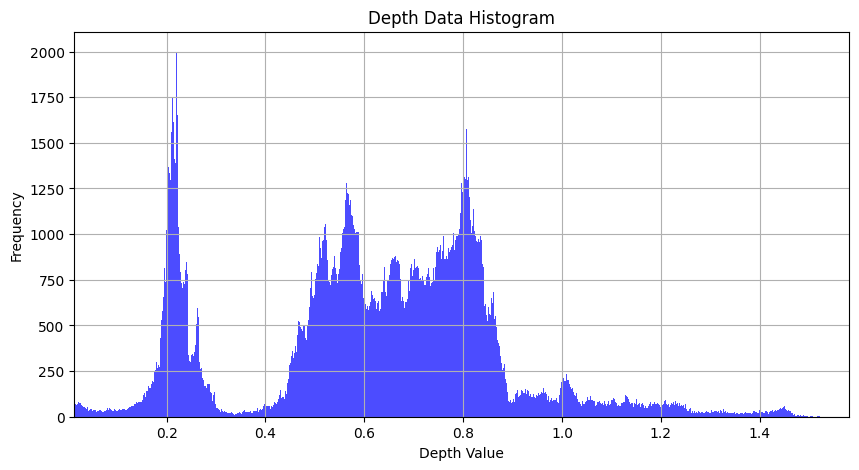

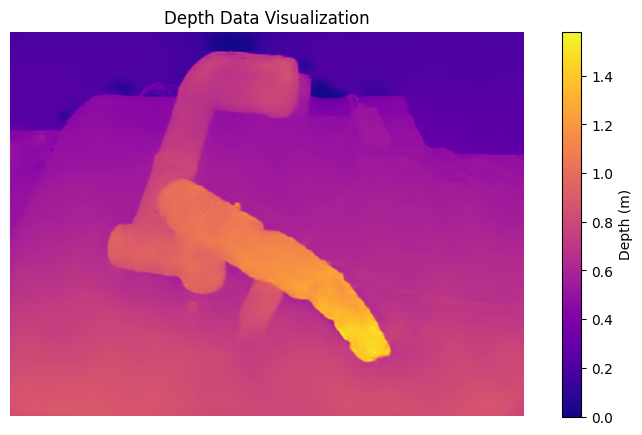

In [52]:
# load npy file
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter


def load_npy(path):
    return np.load(path, allow_pickle=True)

npy_path = 'datasets/robot/robot/metric_depth/026560.npy'
npy_path = 'datasets/robot/ur5_ep1/metric_depth/frame_000000.npy'
# npy_path = 'new_data/ep1/depth_data/frame_000056.npy'
data = load_npy(npy_path)
# data[data > 1000] = 0.5  # Mask out invalid depth values
print(data.shape)
data_filtered = data[data < 10000]  # Filter out values greater than 20
print(data.min(), data.max(), data.mean())

# visualize the depth data as histogram
plt.figure(figsize=(10, 5))
plt.hist(data_filtered.flatten(), bins=1000, color='blue', alpha=0.7)
plt.title('Depth Data Histogram')
plt.xlabel('Depth Value')
plt.ylabel('Frequency')
plt.xlim(data_filtered.min(), data_filtered.max())  # Adjust x-axis limit to focus on relevant depth values
plt.grid()
plt.show()

# plot the depth data as image
plt.figure(figsize=(10, 5))
plt.imshow(data, cmap='plasma', vmin=0, vmax=data_filtered.max())
plt.colorbar(label='Depth (m)')
plt.title('Depth Data Visualization')
plt.axis('off')  # Hide axes for better visualization
plt.show()

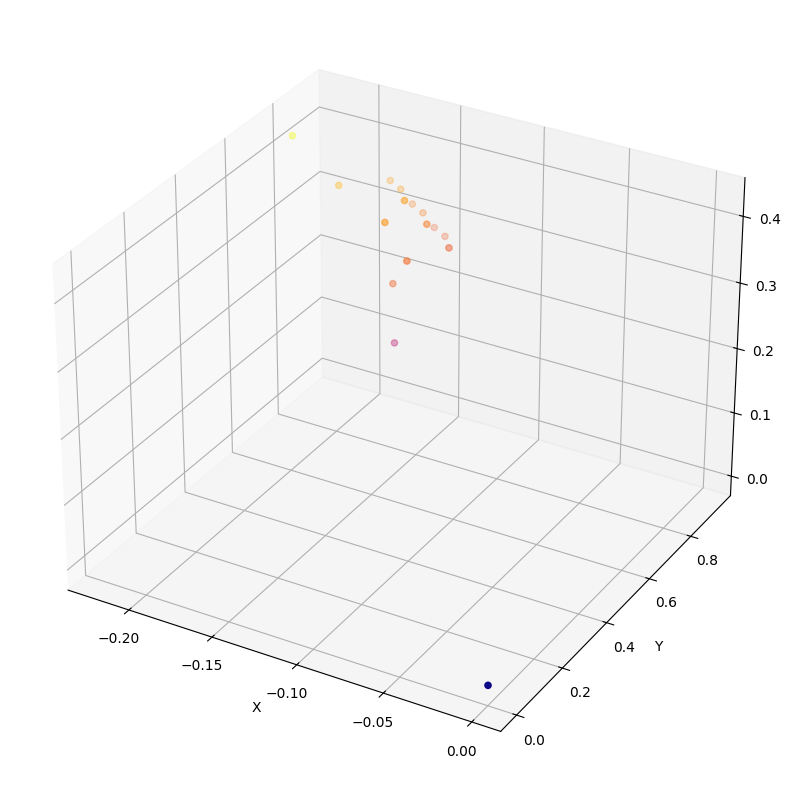

In [7]:
# visualize these 3D points
import torch
import matplotlib.pyplot as plt
def visualize_3d_points(points):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=20, c=points[:, 2], cmap='plasma')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()


data = np.array([[0.0000,  0.0000,  0.0000],
                [-0.1430,  0.6536,  0.1963],
                [-0.1425,  0.6433,  0.2904],
                [-0.1453,  0.7251,  0.2994],
                [-0.1453,  0.7251,  0.2994],
                [-0.1647,  0.8559,  0.3418],
                [-0.1647,  0.8559,  0.3418],
                [-0.1724,  0.8951,  0.3433],
                [-0.1827,  0.9233,  0.3421],
                [-0.1516,  0.8595,  0.3134],
                [-0.1516,  0.8595,  0.3134],
                [-0.1593,  0.8987,  0.3148],
                [-0.1696,  0.9269,  0.3136],
                [-0.1386,  0.8631,  0.2850],
                [-0.1386,  0.8631,  0.2850],
                [-0.1463,  0.9023,  0.2864],
                [-0.1566,  0.9304,  0.2852],
                [-0.1634,  0.7600,  0.3359],
                [-0.1634,  0.7600,  0.3359],
                [-0.1939,  0.7776,  0.3670],
                [-0.2211,  0.7711,  0.4262]], dtype=np.float32)
data = torch.tensor(data)
visualize_3d_points(data)